In [164]:
import pandas as pd
from sklearn.utils.extmath import density

from Functions import nutrition_profile

In [165]:
data = pd.read_csv('cleaned_nutrition_dataset_per100g.csv')
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Vitamin C (mg per 100g)     3454 non-null   float64
 1   Vitamin B11 (mg per 100g)   3454 non-null   float64
 2   Sodium (mg per 100g)        3454 non-null   float64
 3   Calcium (mg per 100g)       3454 non-null   float64
 4   Carbohydrates (g per 100g)  3454 non-null   float64
 5   food                        3454 non-null   object 
 6   Iron (mg per 100g)          3454 non-null   float64
 7   Calories (kcal per 100g)    3454 non-null   float64
 8   Sugars (g per 100g)         3454 non-null   float64
 9   Dietary Fiber (g per 100g)  3454 non-null   float64
 10  Fat (g per 100g)            3454 non-null   float64
 11  Protein (g per 100g)        3454 non-null   float64
 12  food_normalized             3454 non-null   object 
dtypes: float64(11), object(2)
memory 

In [166]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Vitamin C (mg per 100g)     3454 non-null   float64
 1   Vitamin B11 (mg per 100g)   3454 non-null   float64
 2   Sodium (mg per 100g)        3454 non-null   float64
 3   Calcium (mg per 100g)       3454 non-null   float64
 4   Carbohydrates (g per 100g)  3454 non-null   float64
 5   food                        3454 non-null   object 
 6   Iron (mg per 100g)          3454 non-null   float64
 7   Calories (kcal per 100g)    3454 non-null   float64
 8   Sugars (g per 100g)         3454 non-null   float64
 9   Dietary Fiber (g per 100g)  3454 non-null   float64
 10  Fat (g per 100g)            3454 non-null   float64
 11  Protein (g per 100g)        3454 non-null   float64
 12  food_normalized             3454 non-null   object 
dtypes: float64(11), object(2)
memory 

In [167]:
data.describe()

,Vitamin C (mg per 100g),Vitamin B11 (mg per 100g),Sodium (mg per 100g),Calcium (mg per 100g),Carbohydrates (g per 100g),Iron (mg per 100g),Calories (kcal per 100g),Sugars (g per 100g),Dietary Fiber (g per 100g),Fat (g per 100g),Protein (g per 100g)
count,3454.000000,3454.000000,3454.000000,3454.000000,3454.000000,3454.000000,3454.000000,3454.000000,3454.000000,3454.000000,3454.000000
mean,9.501021,11.447140,141.437806,53.953960,18.724570,1.627954,227.591546,5.693513,2.157695,12.006807,10.819314
std,70.387542,33.849817,973.168394,103.339195,26.232674,4.384574,336.277025,13.136356,4.748876,26.726515,27.250089
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029000,0.057000,4.647500,1.700000,0.200000,60.050000,0.000000,0.000000,0.500000,1.262500
50%,0.300000,0.075000,0.200000,21.940000,9.110000,0.700000,134.415000,0.920000,0.710000,4.105000,3.800000
75%,5.382500,4.327500,21.372500,60.600000,26.400000,1.600000,285.007500,5.207500,2.327500,12.500000,9.242500
max,3872.000000,550.520000,14174.590000,1283.500000,390.200000,121.200000,6077.000000,291.500000,76.500000,550.700000,560.300000


In [168]:
data.value_counts()

Vitamin C (mg per 100g)  Vitamin B11 (mg per 100g)  Sodium (mg per 100g)  Calcium (mg per 100g)  Carbohydrates (g per 100g)  food                          Iron (mg per 100g)  Calories (kcal per 100g)  Sugars (g per 100g)  Dietary Fiber (g per 100g)  Fat (g per 100g)  Protein (g per 100g)  food_normalized             
0.00                     0.000                      0.000                 0.00                   0.00                        almond oil                    0.00                120.00                    0.00                 0.00                        13.60             0.00                  almond oil                      1
                                                                                                                             apple juice martinellis       0.00                122.00                    0.00                 0.00                        0.00              0.00                  apple juice martinellis         1
                                 

In [169]:
data.nunique()

Vitamin C (mg per 100g)       1003
Vitamin B11 (mg per 100g)      980
Sodium (mg per 100g)          1120
Calcium (mg per 100g)         1884
Carbohydrates (g per 100g)    1463
food                          3454
Iron (mg per 100g)             490
Calories (kcal per 100g)      1622
Sugars (g per 100g)            989
Dietary Fiber (g per 100g)     608
Fat (g per 100g)              1264
Protein (g per 100g)          1128
food_normalized               3432
dtype: int64

In [170]:
data['food'].unique()

array(['margarine with yoghurt', 'sunflower seed butter', 'hazelnut oil',
       ..., 'creme brulee', 'croque madame', 'cup cakes'],
      shape=(3454,), dtype=object)

In [171]:
data['Fat (g per 100g)'].value_counts()

Fat (g per 100g)
0.20     140
0.00     123
0.30     105
0.40      87
0.10      70
        ... 
6.55       1
0.24       1
54.30      1
78.77      1
7.05       1
Name: count, Length: 1264, dtype: int64

In [172]:
data.duplicated().sum()

np.int64(0)

In [173]:
data["preparation"] = data["food"].str.split().str[-1]

data["preparation"] = data["preparation"].where(
    data["preparation"].isin(["raw", "cooked"]),
    "other"
)

In [174]:
import numpy as np
#Defining the target Daily Values (DVs)
dvs = {
    'Vitamin C (mg per 100g)': 90.0,
    'Vitamin B11 (mg per 100g)': 0.4, # 400 mcg = 0.4 mg
    'Calcium (mg per 100g)': 1300.0,
    'Iron (mg per 100g)': 18.0
}

#a container that will store the score for nutrient density
micro_score = pd.Series(0.0, index=data.index)

# adding , suming up and capping values while filling places with 0 instead of Nan
for col, dv in dvs.items():
    if col in data.columns:
        percent_dv = (data[col] / dv * 100).fillna(0).clip(upper=100)
        micro_score += percent_dv

# this is the new feature that is calculated by finding the score by calculating the % of micro_score/cals
data['micronutrient_density'] = np.where(
    data['Calories (kcal per 100g)'] > 0,
    (micro_score / data['Calories (kcal per 100g)']) * 100,
    micro_score
)

In [175]:
data[['micronutrient_density','Fat (g per 100g)','Protein (g per 100g)','Carbohydrates (g per 100g)','Dietary Fiber (g per 100g)','food']]

,micronutrient_density,Fat (g per 100g),Protein (g per 100g),Carbohydrates (g per 100g),Dietary Fiber (g per 100g),food
0,24.950563,9.8,0.058,0.073,0.0,margarine with yoghurt
1,6.432271,8.8,2.800,3.700,0.9,sunflower seed butter
2,0.000000,13.6,0.000,0.000,0.0,hazelnut oil
3,0.000000,218.0,0.000,0.000,0.0,menhaden fish oil
4,0.000000,13.6,0.000,0.000,0.0,cod liver fish oil
...,...,...,...,...,...,...
3449,9.863966,10.0,12.000,25.000,2.0,clam chowder
3450,9.133302,15.0,18.000,20.000,2.0,crab cakes
3451,8.219972,16.0,7.000,35.000,0.0,creme brulee
3452,7.706223,18.0,14.000,30.000,1.0,croque madame


In [176]:
data.columns

Index(['Vitamin C (mg per 100g)', 'Vitamin B11 (mg per 100g)',
       'Sodium (mg per 100g)', 'Calcium (mg per 100g)',
       'Carbohydrates (g per 100g)', 'food', 'Iron (mg per 100g)',
       'Calories (kcal per 100g)', 'Sugars (g per 100g)',
       'Dietary Fiber (g per 100g)', 'Fat (g per 100g)',
       'Protein (g per 100g)', 'food_normalized', 'preparation',
       'micronutrient_density'],
      dtype='object')

In [177]:
macros = ['Fat (g per 100g)','Carbohydrates (g per 100g)','Protein (g per 100g)', 'Dietary Fiber (g per 100g)','Calories (kcal per 100g)','micronutrient_density']

In [178]:
relation = data[macros].corr()

In [179]:
import matplotlib.pyplot as pl
import seaborn as sns

<Axes: >

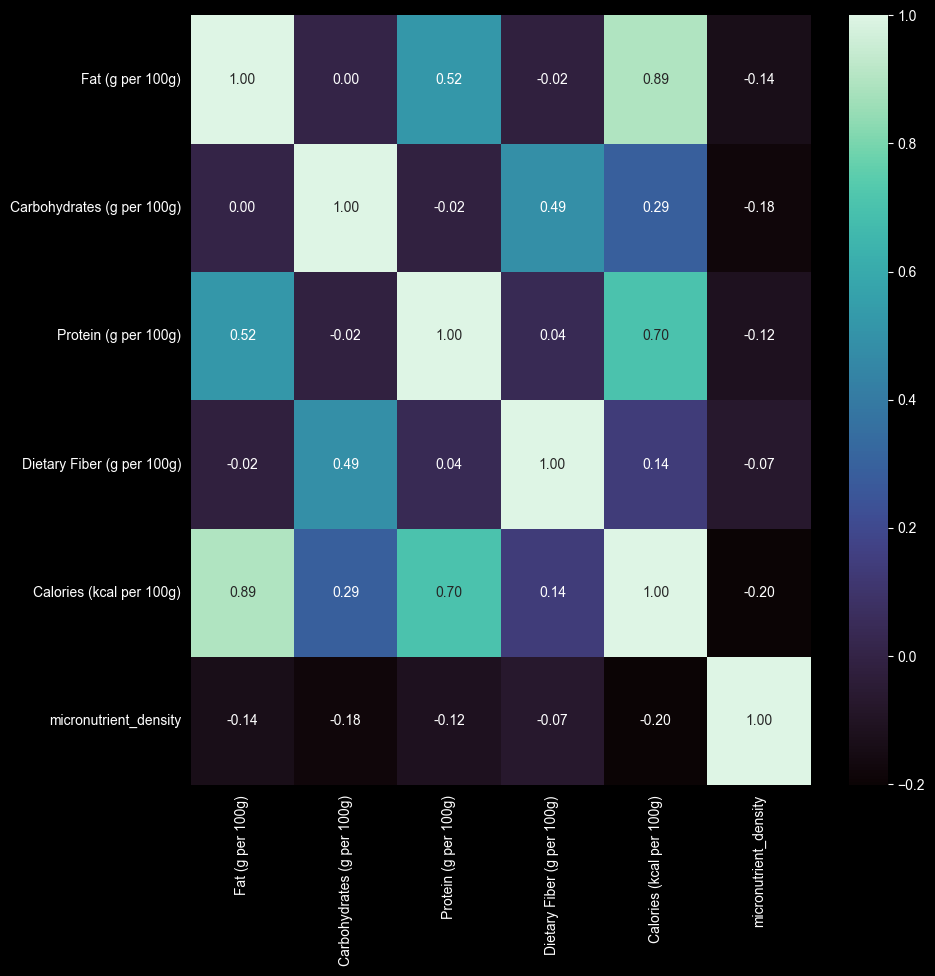

In [180]:
pl.figure(figsize=(10,10))
sns.heatmap(relation,cmap='mako',fmt='.2f',annot=True)

<Figure size 1000x1000 with 0 Axes>

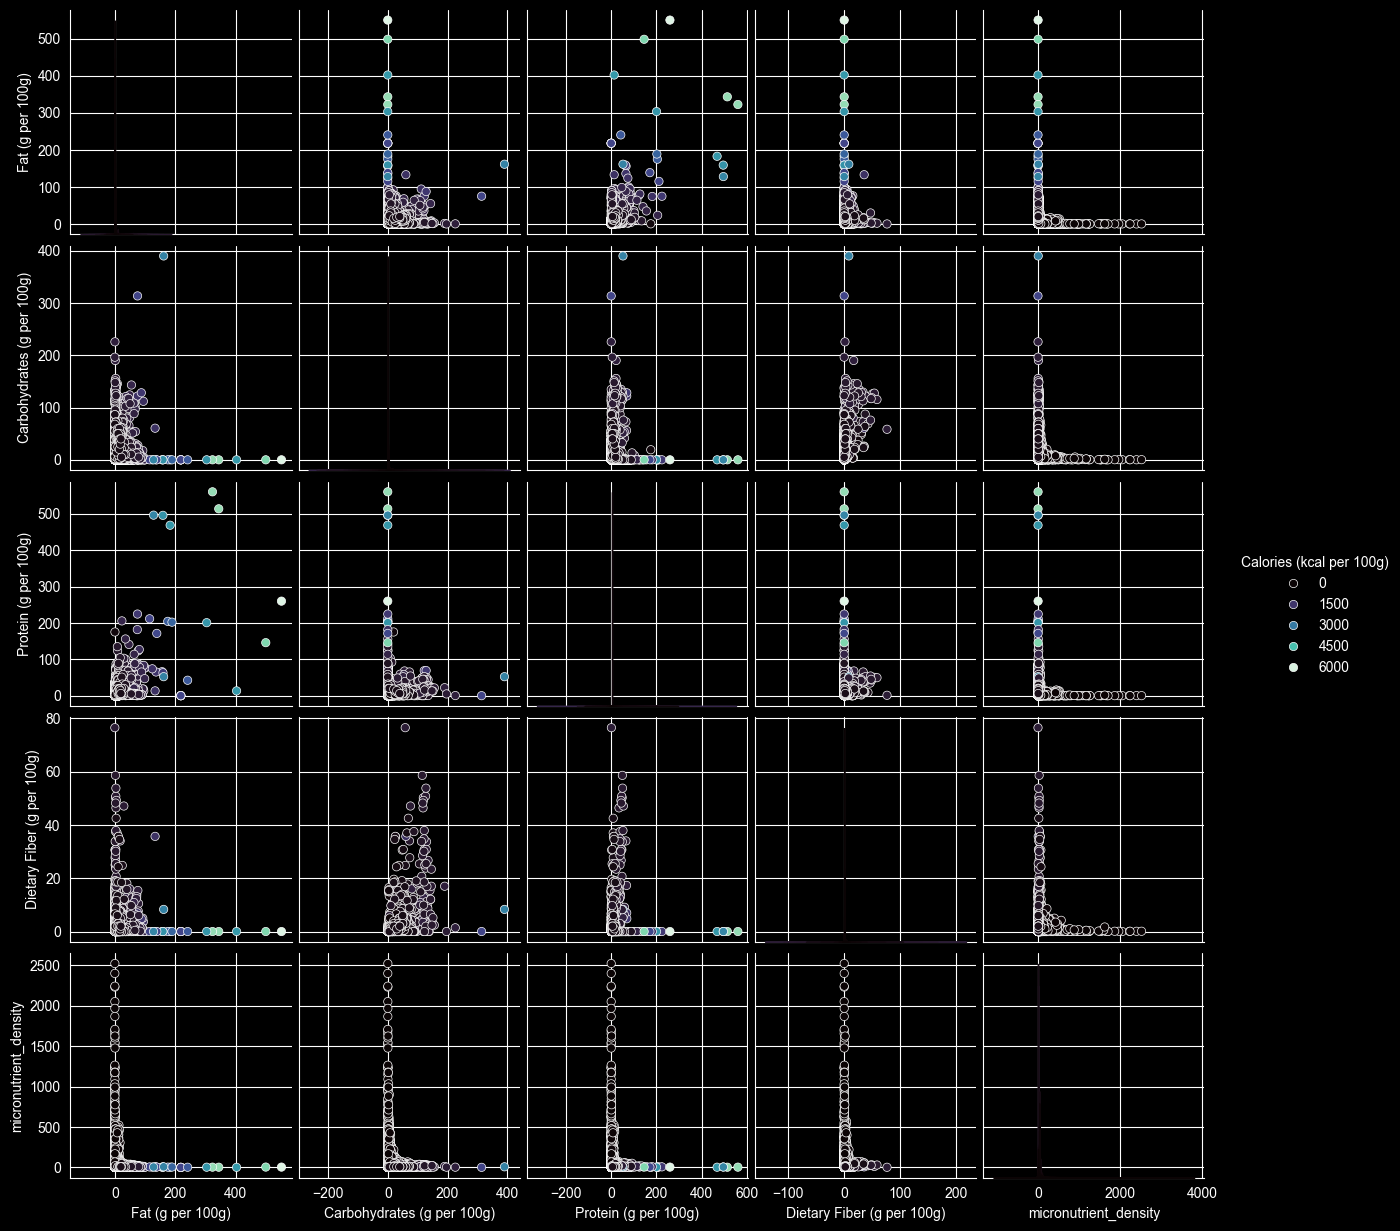

In [181]:
pl.figure(figsize=(10,10))
sns.pairplot(data[macros],palette='mako',hue='Calories (kcal per 100g)')

In [182]:
df = data[
    (data["Protein (g per 100g)"] <= 100) &
    (data["Fat (g per 100g)"] <= 100) &
    (data["Carbohydrates (g per 100g)"] <= 100) &
    (data["Dietary Fiber (g per 100g)"] <= 100)
]

In [183]:
macro = df[macros].copy()

In [184]:
macro.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3331 entries, 0 to 3453
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Fat (g per 100g)            3331 non-null   float64
 1   Carbohydrates (g per 100g)  3331 non-null   float64
 2   Protein (g per 100g)        3331 non-null   float64
 3   Dietary Fiber (g per 100g)  3331 non-null   float64
 4   Calories (kcal per 100g)    3331 non-null   float64
 5   micronutrient_density       3331 non-null   float64
dtypes: float64(6)
memory usage: 182.2 KB


<Axes: xlabel='Fat (g per 100g)', ylabel='Protein (g per 100g)'>

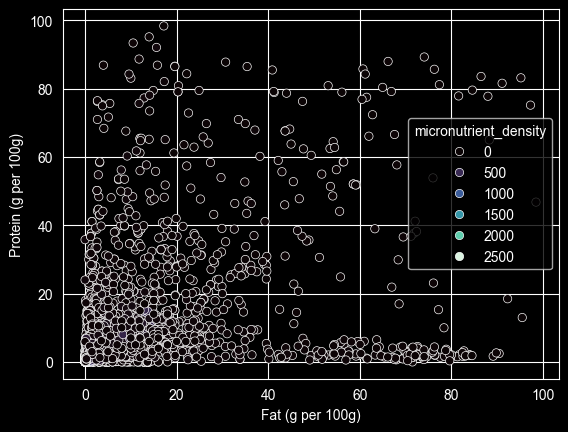

In [185]:
pl.figure()
sns.scatterplot(x ='Fat (g per 100g)' , y = 'Protein (g per 100g)',marker='o',data=macro,hue='micronutrient_density',palette='mako')

In [186]:
macros = ['Fat (g per 100g)','Carbohydrates (g per 100g)','Protein (g per 100g)', 'Dietary Fiber (g per 100g)','micronutrient_density']
relate = macro[macros].corr()

<Axes: >

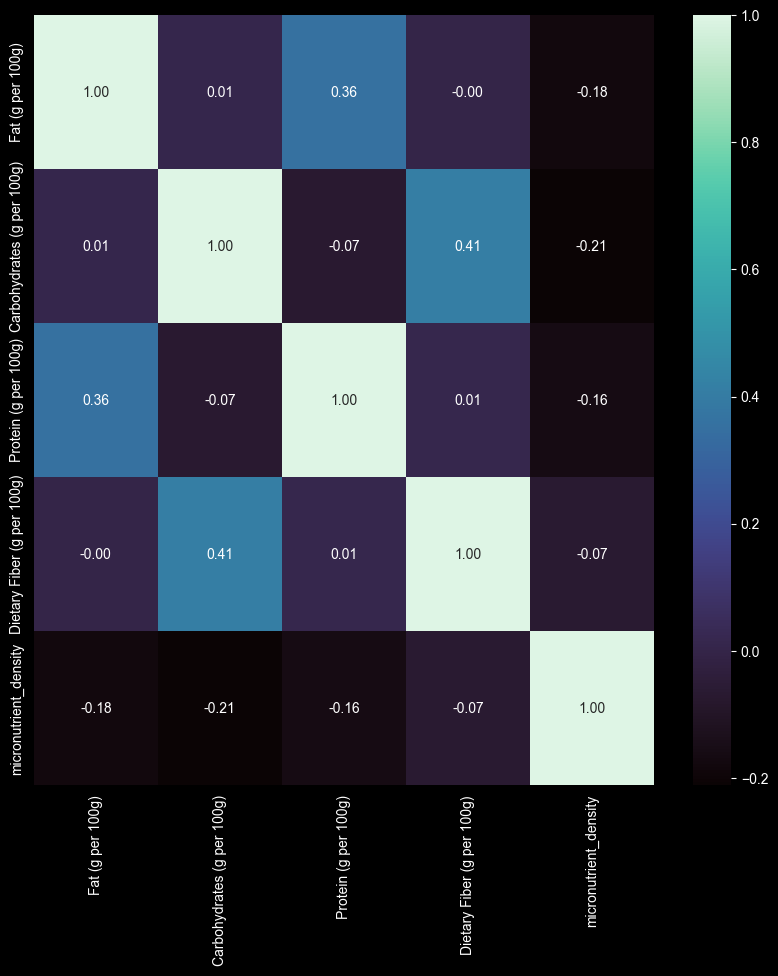

In [187]:
pl.figure(figsize=(10,10))
sns.heatmap(relate,cmap='mako',fmt='.2f',annot=True)

<Figure size 1000x1000 with 0 Axes>

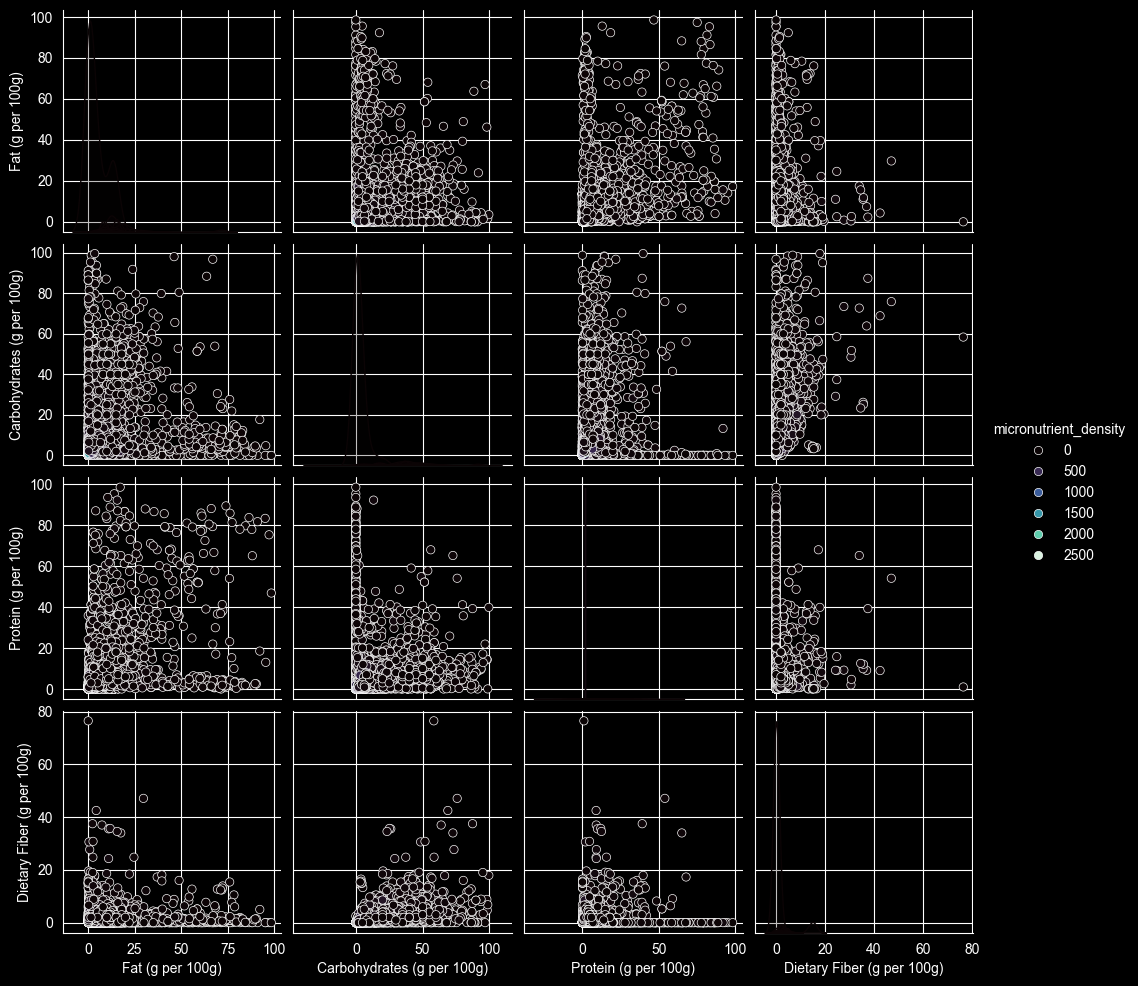

In [188]:
pl.figure(figsize=(10,10))
sns.pairplot(macro[macros],palette='mako',hue='micronutrient_density')

<Axes: xlabel='Protein (g per 100g)', ylabel='Density'>

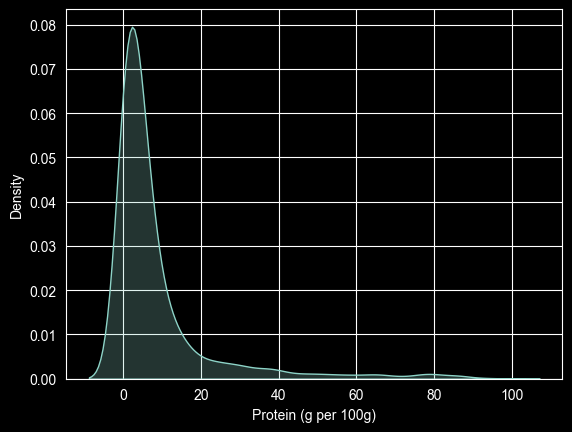

In [189]:
sns.kdeplot(data=macro,x='Protein (g per 100g)',fill=True)

<Axes: xlabel='Fat (g per 100g)', ylabel='Density'>

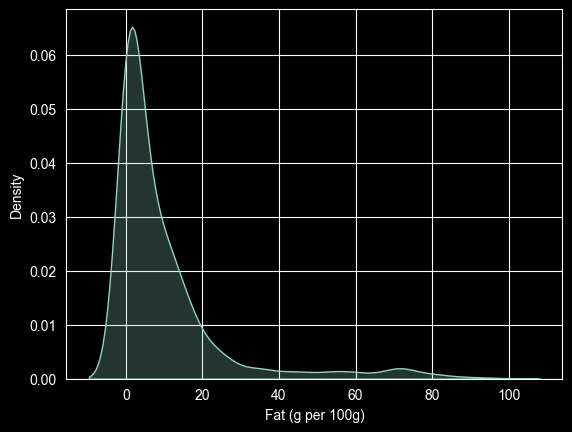

In [190]:
sns.kdeplot(data=macro,x='Fat (g per 100g)',fill=True)

<Axes: xlabel='Dietary Fiber (g per 100g)', ylabel='Density'>

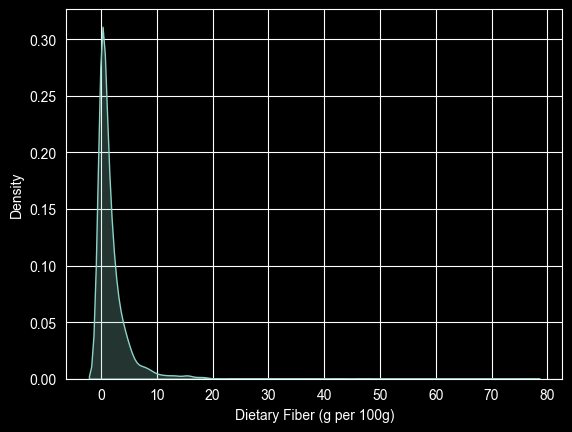

In [191]:
sns.kdeplot(data=macro,x='Dietary Fiber (g per 100g)',fill=True)

<Axes: xlabel='Carbohydrates (g per 100g)', ylabel='Density'>

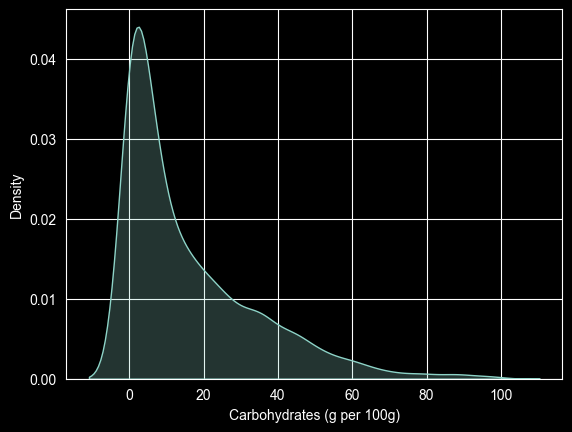

In [192]:
sns.kdeplot(data=macro,x='Carbohydrates (g per 100g)',fill=True)

<Axes: xlabel='Calories (kcal per 100g)', ylabel='Density'>

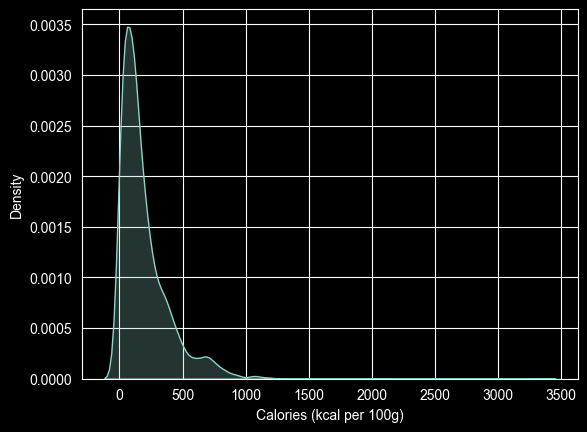

In [193]:
sns.kdeplot(data=macro,x='Calories (kcal per 100g)',fill=True)

In [194]:
data[macros].columns

Index(['Fat (g per 100g)', 'Carbohydrates (g per 100g)',
       'Protein (g per 100g)', 'Dietary Fiber (g per 100g)',
       'micronutrient_density'],
      dtype='object')

In [195]:
macro.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3331 entries, 0 to 3453
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Fat (g per 100g)            3331 non-null   float64
 1   Carbohydrates (g per 100g)  3331 non-null   float64
 2   Protein (g per 100g)        3331 non-null   float64
 3   Dietary Fiber (g per 100g)  3331 non-null   float64
 4   Calories (kcal per 100g)    3331 non-null   float64
 5   micronutrient_density       3331 non-null   float64
dtypes: float64(6)
memory usage: 182.2 KB


In [196]:
from sklearn.cluster import KMeans

In [197]:
x = macro[macros].drop('micronutrient_density',axis=1)

In [198]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [199]:
kmeans = KMeans(n_clusters=8,random_state=42)
kmeans.fit(x)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [200]:
labels = kmeans.predict(x)
macro['clusters'] = labels

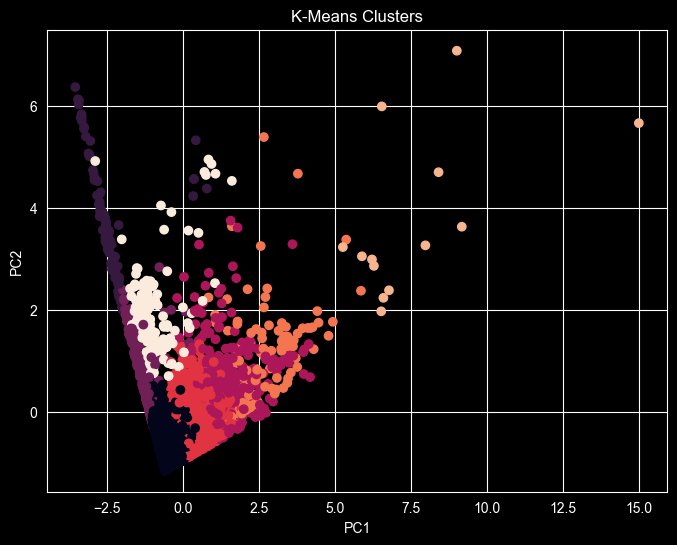

In [201]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

x_pca = pca.fit_transform(x)

plt.figure(figsize=(8, 6))
plt.scatter(
    x_pca[:, 0],
    x_pca[:, 1],
    c=labels
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters")
plt.show()

In [202]:
cluster_summary = macro.groupby("clusters")[[
    "Fat (g per 100g)",
    "Carbohydrates (g per 100g)",
    "Protein (g per 100g)",
    "Dietary Fiber (g per 100g)",
    "micronutrient_density"
]].mean()

cluster_summary

,Fat (g per 100g),Carbohydrates (g per 100g),Protein (g per 100g),Dietary Fiber (g per 100g),micronutrient_density
clusters,,,,,
0,3.887226,5.223182,3.096887,0.798277,138.986683
1,38.912727,2.269236,70.955455,0.310000,11.598439
2,12.794932,2.335416,31.857557,0.242529,17.951470
3,13.915311,55.937475,8.899879,2.661902,18.393008
4,7.092577,26.312307,5.184704,2.177785,36.370134
5,6.264160,37.401040,11.404480,12.015280,32.974161
6,9.842308,56.490000,18.733077,38.025385,35.778870
7,65.881745,8.838322,5.442215,1.934966,17.883012


In [203]:
from sklearn.metrics import silhouette_score
x = macro.drop(columns='micronutrient_density')

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

for k in range(2, 13):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x_scaled)

    score = silhouette_score(x_scaled, labels)
    print(k, score)

2 0.4141932520614208
3 0.48316507579992696
4 0.5166074965368681
5 0.5290228446349592
6 0.5056202458851765
7 0.5229269322549038
8 0.51723199445405
9 0.5132406033201142
10 0.5242794893495826
11 0.49090618206250064
12 0.48599739193190433


In [204]:
kmeans = KMeans(n_clusters=8, random_state=42)
labels = kmeans.fit_predict(x_scaled)

macro["clusters"] = labels

macro.groupby("clusters")[[
    "Fat (g per 100g)",
    "Carbohydrates (g per 100g)",
    "Protein (g per 100g)",
    "Dietary Fiber (g per 100g)",
    "micronutrient_density"
]].mean()

,Fat (g per 100g),Carbohydrates (g per 100g),Protein (g per 100g),Dietary Fiber (g per 100g),micronutrient_density
clusters,,,,,
0,3.877172,5.210411,3.146772,0.796325,138.752215
1,12.966790,52.433289,10.148045,4.679390,21.094880
2,53.124138,45.965517,33.958621,7.237931,11.982420
3,65.591348,8.146170,3.959504,1.423475,18.195451
4,12.455517,2.081151,34.899655,0.231030,17.205953
5,44.088636,0.213818,72.123864,0.000000,11.262136
6,6.145129,26.346753,4.791156,2.585881,36.577341
7,9.427333,53.394667,17.444000,36.228667,37.950335


In [205]:
macro["clusters"].value_counts().sort_index()

clusters
0    1636
1     377
2      29
3     141
4     232
5      88
6     813
7      15
Name: count, dtype: int64

In [206]:
data.loc[macro.index][
    macro["clusters"] == 7
]["food"].head(20)

443             oriental radish dried
922                        lupins raw
1537                        rose hips
1585                    chokecherries
1691                    oregano dried
1703                      thyme dried
1732                   fava beans raw
1766                 winged beans raw
2119                 dessert wine dry
2300                        rice bran
2313                       wheat bran
3272                 Pav bhaji masala
3384                     Garam masala
3387      Rasam powder (Rasam masala)
3388    Sambar powder (Sambar masala)
Name: food, dtype: object

In [207]:
for cluster in sorted(macro["clusters"].unique()):
    print(f"\nCluster {cluster}")
    print(data.loc[macro.index[macro["clusters"] == cluster], "food"].unique())


Cluster 0
['margarine with yoghurt' 'sunflower seed butter' 'hazelnut oil' ...
 'Tomato ketchup' 'caesar salad' 'caprese salad']

Cluster 1
['vegetable macaroni dry' 'corn pasta dry' 'whole wheat macaroni dry'
 'macaroni raw' 'pasta cooked' 'spaghetti cooked' 'bread crumbs'
 'tortilla' 'sweet cinnamon rolls' 'frybread' 'bagel' 'biscuit'
 'chocolate wafers' 'vanilla wafers low fat' 'graham crackers'
 'tropical trail mix' 'soft pretzels' 'cracker meal' 'russet potato raw'
 'russet potato baked' 'corn chips unsalted' 'soy flour roasted'
 'soy flour low fat' 'soybean dry roasted' 'green soybean raw'
 'acorn squash raw' 'poi' 'rhubarb cooked' 'pupusas con frijoles'
 'cassava' 'chowchow pickles' 'avocado' 'taro cooked' 'split peas cooked'
 'rutabaga raw' 'sweet mashed potato canned' 'tomato paste canned'
 'potato salad with egg' 'corn pudding' 'instant coffee powder'
 'apple juice concentrate' 'cream soda' 'ginkgo nuts canned'
 'chestnuts raw' 'muesli with fruit nuts' 'nut cereal' 'corn tam

In [208]:
cluster_profile = macro.groupby("clusters")[
    [
        "Fat (g per 100g)",
        "Carbohydrates (g per 100g)",
        "Protein (g per 100g)",
        "Dietary Fiber (g per 100g)",
        "micronutrient_density"
    ]
].mean().round(2)

cluster_profile["food_count"] = macro["clusters"].value_counts().sort_index()
cluster_profile

,Fat (g per 100g),Carbohydrates (g per 100g),Protein (g per 100g),Dietary Fiber (g per 100g),micronutrient_density,food_count
clusters,,,,,,
0,3.88,5.21,3.15,0.80,138.75,1636
1,12.97,52.43,10.15,4.68,21.09,377
2,53.12,45.97,33.96,7.24,11.98,29
3,65.59,8.15,3.96,1.42,18.20,141
4,12.46,2.08,34.90,0.23,17.21,232
5,44.09,0.21,72.12,0.00,11.26,88
6,6.15,26.35,4.79,2.59,36.58,813
7,9.43,53.39,17.44,36.23,37.95,15


In [209]:
final_data = df.loc[macro.index].copy()
final_data["clusters"] = macro["clusters"]
final_data=final_data.drop(columns='food_normalized',axis=1)

In [210]:
data["preparation"] = data["food"].str.split().str[-1]

data["preparation"] = data["preparation"].where(
    data["preparation"].isin(["raw", "cooked"]),
    "other"
)

In [211]:
final_data.shape

(3331, 15)

In [212]:
final_data.columns

Index(['Vitamin C (mg per 100g)', 'Vitamin B11 (mg per 100g)',
       'Sodium (mg per 100g)', 'Calcium (mg per 100g)',
       'Carbohydrates (g per 100g)', 'food', 'Iron (mg per 100g)',
       'Calories (kcal per 100g)', 'Sugars (g per 100g)',
       'Dietary Fiber (g per 100g)', 'Fat (g per 100g)',
       'Protein (g per 100g)', 'preparation', 'micronutrient_density',
       'clusters'],
      dtype='object')

In [213]:
final_data.to_csv('clustered_food_database.csv', index=False)